<a href="https://colab.research.google.com/github/Swastika-Roy/Python-concepts/blob/main/MissingDataAnalysisAndTreatment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/01_missing_values.csv')
print('Dataset shape: ',df.shape)
print("\\n" + "=" *80)
# print("Dataset Shape", df.shape)
print("Dimension", df.ndim)
print("Size", df.size)
print("Column Names",df.columns.tolist())
print("Index",df.index.tolist())
print("Data Types \n",df.dtypes)
df.describe()
print("Information about 'df'")
df.info()

Dataset shape:  (20, 11)
\n================================================================================
Dataset Shape (20, 11)
Dimension 2
Size 220
Column Names ['Employee_ID', 'First_Name', 'Last_Name', 'Email', 'Phone', 'Department', 'Salary', 'Hire_Date', 'Manager_ID', 'Office_Location', 'Years_Experience']
Index [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Data Types 
 Employee_ID          object
First_Name           object
Last_Name            object
Email                object
Phone                object
Department           object
Salary              float64
Hire_Date            object
Manager_ID           object
Office_Location      object
Years_Experience    float64
dtype: object
Information about 'df'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       20 non-null     object 
 1   

In [5]:
print("Missing Values")
#calculate
total_cells = df.size
miss = df.isnull().sum().sum()

print(f"dim : {df.shape[0]} rows x {df.shape[1]} cols" )
print(total_cells)
print(miss)
print(f"Missing Cells Percentage : {round((miss/total_cells)*100,2)}%")

Missing Values
dim : 20 rows x 11 cols
220
61
Missing Cells Percentage : 27.73%


In [9]:
from pandas.core.dtypes.missing import notnull
from pandas.core.dtypes import dtypes
#detailed breakdown
#missing  values by col
missing_data = pd.DataFrame(
    {
        'col': df.columns,
        'missing_count': df.isnull().sum(),
        'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2),
        'DATA-TYPE': df.dtypes,
        'Non-null-count': df.notnull().sum()
    }
)
miss_data = missing_data.sort_values(by='missing_percentage', ascending=False)
print(miss_data.to_string(index=False))

             col  missing_count  missing_percentage DATA-TYPE  Non-null-count
 Office_Location              8                40.0    object              12
           Email              7                35.0    object              13
       Hire_Date              7                35.0    object              13
      Manager_ID              7                35.0    object              13
          Salary              6                30.0   float64              14
           Phone              6                30.0    object              14
      Department              6                30.0    object              14
       Last_Name              5                25.0    object              15
Years_Experience              5                25.0   float64              15
      First_Name              4                20.0    object              16
     Employee_ID              0                 0.0    object              20


In [12]:
print("missing values by row")
rows_with_missing_values = df[df.isnull().any(axis=1)]
print(f" {len(rows_with_missing_values)} out of {len(df)} rows have missing values ({len(rows_with_missing_values)/len(df)*100:.1f}%)")

missing values by row
 19 out of 20 rows have missing values (95.0%)


In [13]:
print("_"*80)
print("Missing Value Patterns (Top 10)")
print("_"*80)

missing_patterns = df.isnull().groupby(df.isnull().apply(lambda x: tuple(x), axis=1)).size()
missing_patterns = missing_patterns.sort_values(ascending=False).head(10)
for i, (pattern, count) in enumerate(missing_patterns.items(),1):
    missing_cols = [col for col, is_missing in zip(df.columns,pattern) if is_missing]
    if missing_cols:
      print(f"{i}. Missing {missing_cols}: {count} rows")
    else:
      print(f"{i}. Complete rows : {count}")

________________________________________________________________________________
Missing Value Patterns (Top 10)
________________________________________________________________________________
1. Complete rows : 1
2. Missing ['Manager_ID']: 1 rows
3. Missing ['Department', 'Years_Experience']: 1 rows
4. Missing ['Department', 'Salary', 'Years_Experience']: 1 rows
5. Missing ['Phone', 'Salary', 'Manager_ID', 'Office_Location']: 1 rows
6. Missing ['Email', 'Hire_Date']: 1 rows
7. Missing ['Email', 'Hire_Date', 'Office_Location', 'Years_Experience']: 1 rows
8. Missing ['Email', 'Hire_Date', 'Manager_ID', 'Office_Location']: 1 rows
9. Missing ['Email', 'Department', 'Hire_Date', 'Office_Location']: 1 rows
10. Missing ['Email', 'Phone', 'Manager_ID', 'Office_Location']: 1 rows


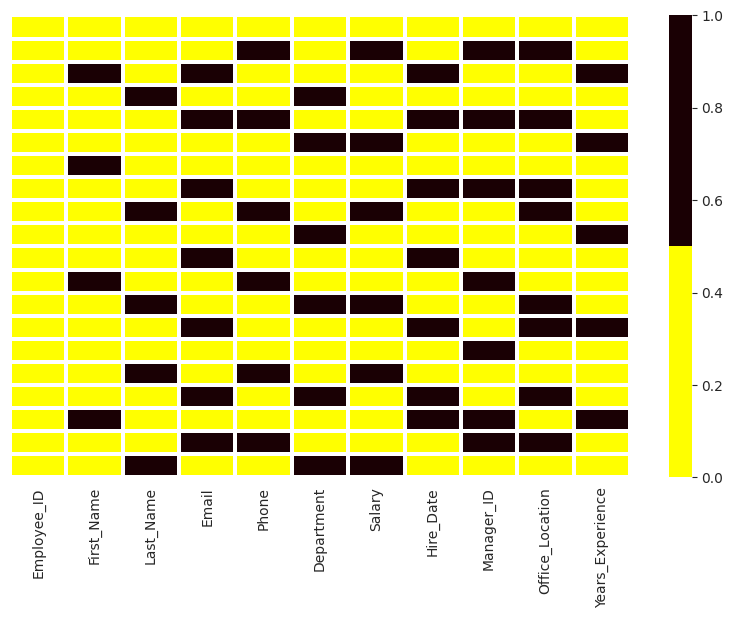

In [16]:
sns.set_style('whitegrid')
#1 Missing Data heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=True,cmap=['#FFFF00','#1A0004'],yticklabels=False,linewidths='1.5',linecolor='white')
plt.show()

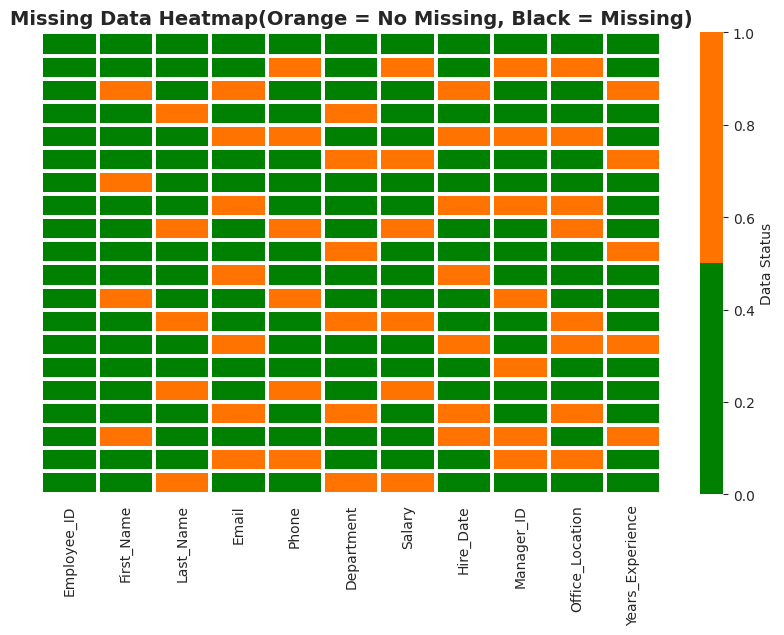

In [17]:
sns.set_style('whitegrid')
#1 Missing Data heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=True, cmap=plt.cm.colors.ListedColormap(['green','#FF7400']),
            yticklabels=False, linewidths=1.5, linecolor='white',
            cbar_kws={'label':'Data Status'})
plt.title('Missing Data Heatmap(Orange = No Missing, Black = Missing)', fontsize=14, fontweight='bold')
plt.show()

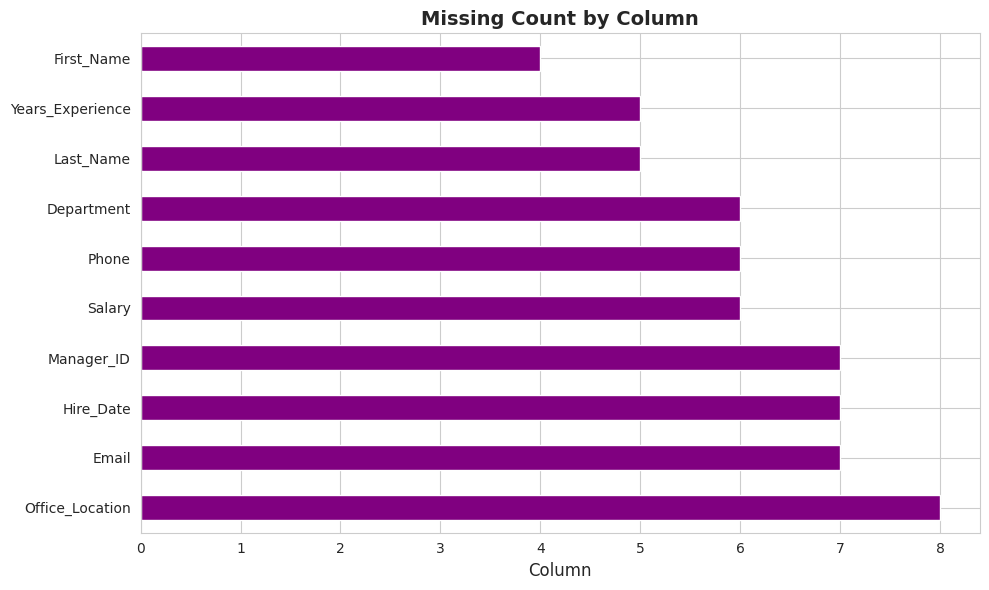

In [20]:
#Missing Count by Column
plt.figure(figsize=(10,6))
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count[missing_count>0].plot(kind='barh',color='purple')
plt.title('Missing Count by Column',fontsize=14,fontweight='bold')
plt.xlabel('Column',fontsize=12)
plt.tight_layout()
plt.show()

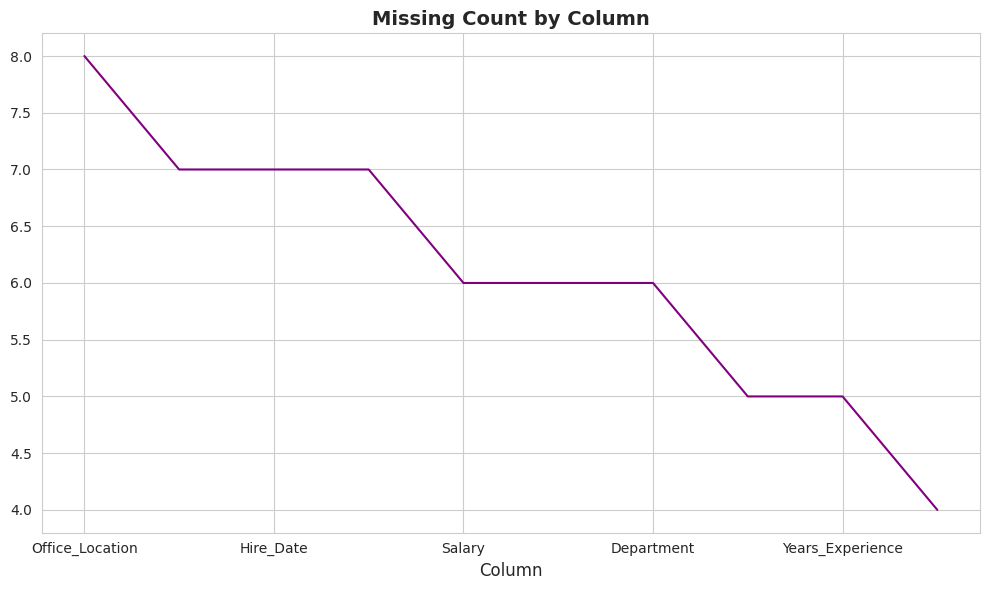

In [23]:
#Missing Count by Column
plt.figure(figsize=(10,6))
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_count[missing_count>0].plot(color='purple')
plt.title('Missing Count by Column',fontsize=14,fontweight='bold')
plt.xlabel('Column',fontsize=12)
plt.tight_layout()
plt.show()

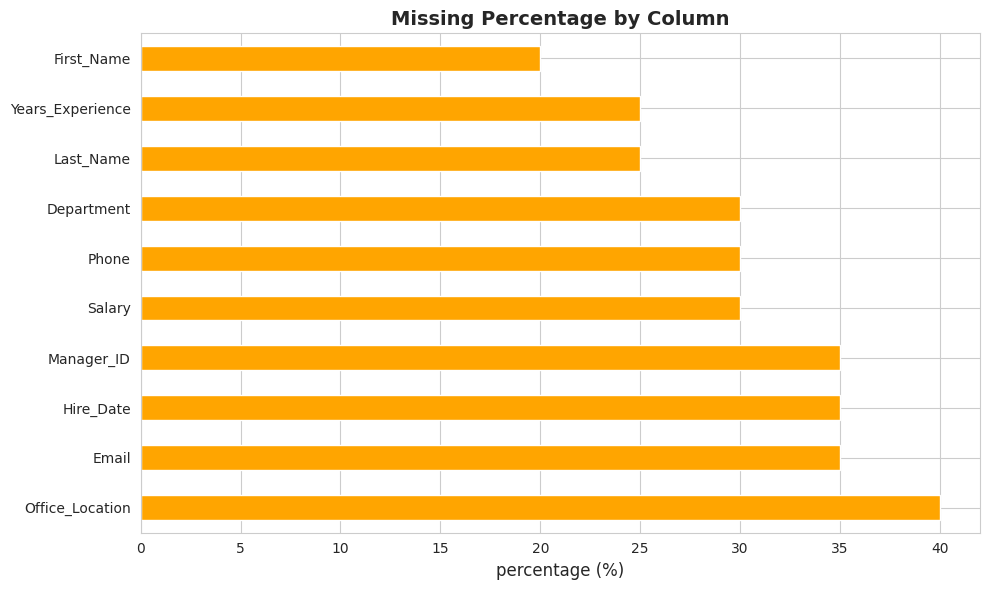

In [30]:
#Missing percentage by Column
plt.figure(figsize=(10,6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct>0].plot(kind='barh',color='orange')
plt.title('Missing Percentage by Column',fontsize=14,fontweight='bold')
plt.xlabel('percentage (%)',fontsize=12)
plt.tight_layout()
plt.show()

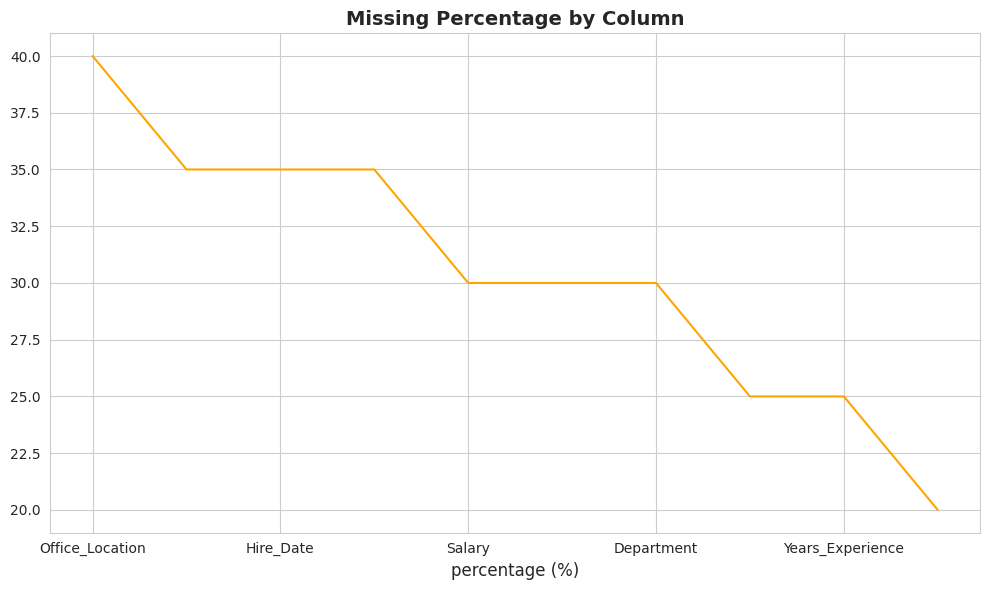

In [31]:
#Missing percentage by Column
plt.figure(figsize=(10,6))
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct[missing_pct>0].plot(color='orange')
plt.title('Missing Percentage by Column',fontsize=14,fontweight='bold')
plt.xlabel('percentage (%)',fontsize=12)
plt.tight_layout()
plt.show()